# Multiple regression using Advertising dataset - student version


Dataset: advertising.csv

## Multiple Linear Regression

Multiple Linear Regression is an extension of Simple Linear regression as it takes more than one predictor variable to predict the response variable. It is an algorithm that models the linear relationship between a single dependent continuous variable and more than one independent variable. It uses two or more independent variables to predict a dependent variable by fitting a best linear relationship.

Equation

$$y=\beta_0+\beta_1*x_1+\beta_2*x_2+..+\beta_n*x_n+e$$

where
- $y$ = Dependent variable / Target variable
- $\beta_0$ = Intercept of the regression line
- $\beta_0, \beta_1, .. \beta_n$ = Slope of the regression line which tells whether the line is increasing or decreasing
- $ x_1, x_2, .. x_n$ = Independent variable / Predictor variable
- e = Error 


Predicting sales based on the money spent on TV, Radio, and Newspaper for marketing. In this case, there are three independent variables, i.e., money spent on TV, Radio, and Newspaper for marketing, and one dependent variable, i.e., sales, that is the value to be predicted.

In [ ]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [21]:
# Reading the dataset
# TODO: read the dataset (ds) and find out the properties
df = pd.read_csv("advertising.csv")
print(df); print()

print(df.describe()); print()

print(f"Amount of NaNs in tv: {sum(np.isnan(df["TV"]))}")
print(f"Amount of NaNs in tv: {sum(np.isnan(df["Newspaper"]))}")
print(f"Amount of NaNs in tv: {sum(np.isnan(df["Radio"]))}")
print(f"Amount of NaNs in tv: {sum(np.isnan(df["Sales"]))}")


        TV  Radio  Newspaper  Sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3   12.0
3    151.5   41.3       58.5   16.5
4    180.8   10.8       58.4   17.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

[200 rows x 4 columns]

               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000

Amount of NaNs in tv: 0
Amount of NaNs in tv: 0
Amount o

In [22]:
# Setting the value for X (=features) and y (=sales)
# TODO: select the features (X) and target (y)

X = df[["TV", "Radio", "Newspaper"]]
y = df[["Sales"]]

print(X); print()
print(y)


        TV  Radio  Newspaper
0    230.1   37.8       69.2
1     44.5   39.3       45.1
2     17.2   45.9       69.3
3    151.5   41.3       58.5
4    180.8   10.8       58.4
..     ...    ...        ...
195   38.2    3.7       13.8
196   94.2    4.9        8.1
197  177.0    9.3        6.4
198  283.6   42.0       66.2
199  232.1    8.6        8.7

[200 rows x 3 columns]

     Sales
0     22.1
1     10.4
2     12.0
3     16.5
4     17.9
..     ...
195    7.6
196   14.0
197   14.8
198   25.5
199   18.4

[200 rows x 1 columns]


In [23]:
# Splitting the dataset
# random_sate controls shuffling applied to the data before applying the split. 
# (pass an int for reproducible output across multiple function calls)
# TODO: Split the dataset into train (X_train, y_train) and test sets (X_test, y_test) use 70/30 ratio

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)

print(f"len of X_train: {X_train.shape}")
print(f"len of X_test: {X_test.shape}")
print(f"len of y_train: {y_train.shape}")
print(f"len of y_test: {y_test.shape}")

print(X_train.head()); print()



len of X_train: (140, 3)
len of X_test: (60, 3)
len of y_train: (140, 1)
len of y_test: (60, 1)
        TV  Radio  Newspaper
169  284.3   10.6        6.4
97   184.9   21.0       22.0
31   112.9   17.4       38.6
12    23.8   35.1       65.9
35   290.7    4.1        8.5



In [24]:
# Note test set is in random order (index values)
print(f"X_train: \n{X_train.iloc[:3]}"); print()
print(f"y_train: \n{y_train.iloc[:3]}"); print()
print(f"X_test: \n{X_test.iloc[:3]}"); print()
print(f"y_test \n{y_test.iloc[:3]}")

X_train: 
        TV  Radio  Newspaper
169  284.3   10.6        6.4
97   184.9   21.0       22.0
31   112.9   17.4       38.6

y_train: 
     Sales
169   20.0
97    20.5
31    11.9

X_test: 
       TV  Radio  Newspaper
95  163.3   31.6       52.9
15  195.4   47.7       52.9
30  292.9   28.3       43.2

y_test 
    Sales
95   16.9
15   22.4
30   21.4


In [25]:
# Fitting the Linear Regression model
# TODO: build LinearRegression model using train data
lm = LinearRegression()
lm.fit(X_train, y_train)

print(lm.coef_)
print(f"tv coef: {lm.coef_[0,0]}, radio coef: {lm.coef_[0,1]}, newspaper coef: {lm.coef_[0,2]}")
print(f"interception: {lm.intercept_}")


[[0.05358869 0.10270677 0.00793167]]
tv coef: 0.05358869132706913, radio coef: 0.10270676778771293, newspaper coef: 0.007931667677316331
interception: [4.7437667]


\# TODO: write the conclusions  

From these results one can conclude the following:
- if no money is used in advertising, the sales is ...
- single money increase spent on TV advertising will increase the sales ...
- single money increase spent on Radio advertising will increase the sales ...
- single money increase spent on Newspaper advertising will increase the sales ...

In [26]:
# Prediction of test set
# TODO: use test set to predict the sales, print the predicted values

y_pred = lm.predict(X_test)

# print predicted values
print(y_pred)

[[17.15991908]
 [20.53369503]
 [23.68914396]
 [ 9.5191455 ]
 [21.60736836]
 [12.78101318]
 [21.08636345]
 [ 8.76054246]
 [17.11499951]
 [16.68789636]
 [ 8.97584663]
 [ 8.57645026]
 [18.33212325]
 [ 8.17863567]
 [12.64605571]
 [14.94486946]
 [ 8.34939536]
 [17.83858948]
 [11.12172174]
 [20.37740648]
 [20.9483297 ]
 [13.04035779]
 [11.01360656]
 [22.51142595]
 [ 9.40369784]
 [ 7.98591291]
 [20.86943368]
 [13.77882255]
 [10.83407064]
 [ 8.00419229]
 [15.88597618]
 [10.7027424 ]
 [20.9521718 ]
 [10.84679243]
 [21.50720813]
 [21.07347295]
 [12.22673775]
 [22.85273767]
 [12.57698182]
 [ 6.54597206]
 [11.93411853]
 [15.23490068]
 [10.07411153]
 [ 9.52159696]
 [17.11786382]
 [ 7.28032677]
 [10.49404864]
 [15.24356754]
 [11.20742176]
 [11.78392665]
 [14.01472163]
 [14.59884572]
 [10.82722434]
 [ 9.55839415]
 [ 9.03749681]
 [12.51183313]
 [10.52551021]
 [25.01900824]
 [ 7.99334943]
 [15.73916263]]


In [27]:
# Actual value and the predicted value
# TODO: Calculate the difference (prediction error)
prediction_error = y_test - y_pred
print(prediction_error)




        Sales
95  -0.259919
15   1.866305
30  -2.289144
158 -2.219146
128  3.092632
115 -0.181013
69   1.213637
170 -0.360542
174 -0.615000
45  -0.587896
66   2.024153
182  0.123550
165 -1.432123
78  -2.878636
186 -2.346056
177  1.755131
56  -2.849395
152 -1.238589
82   0.178278
68  -1.477406
124 -1.248330
16  -0.540358
148 -0.113607
93  -0.311426
65   1.896302
60   0.114087
84   0.830566
67  -0.378823
125 -0.234071
132 -2.304192
9   -0.285976
18   0.597258
55   2.747828
75  -2.146792
150 -5.407208
104 -0.373473
135 -0.626738
137 -2.052738
164 -0.676982
76   0.354028
79  -0.934119
197 -0.434901
38   0.025888
24   0.178403
122 -0.517864
195  0.319673
29   0.005951
19  -0.643568
143 -0.807422
86   0.216073
114  0.585278
173  2.101154
5   -3.627224
126 -2.958394
117  0.362503
73  -1.511833
140  0.374490
98   0.380992
172 -0.393349
96   0.960837


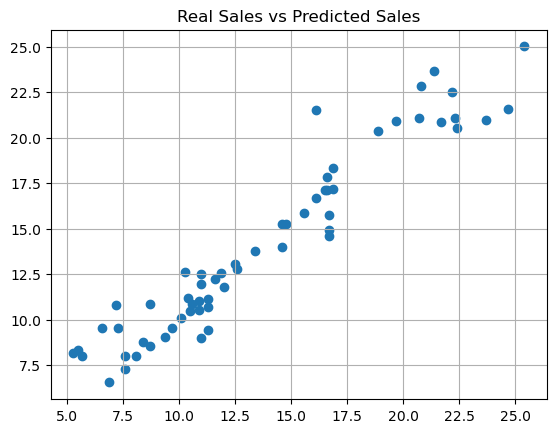

In [33]:
# visualize the results
# TODO: Use scatter plot to visualize the test and predicted values
plt.scatter(x = y_test, y = y_pred)
plt.grid()
plt.title("Real Sales vs Predicted Sales")
plt.show()



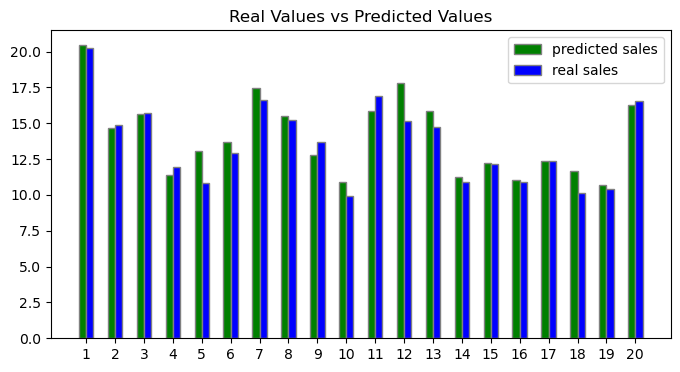

In [34]:
# TODO: visualize the differences using bar plot
# i will combine every 10 values into one bar
# i am not sure if this is what was supposed to be done here

avrg_y_pred = [np.mean(y_pred[i:i+3]) for i in range(0, len(y_pred), 3) ]
avrg_y_real = [np.mean(y_test.values[i:i+3]) for i in range(0, len(y_test.values), 3)]

barWidth = 0.25
x_axis = np.arange(21)
x_axis = np.delete(x_axis, 0)

fig = plt.figure(figsize=(8,4))
plt.bar(x_axis - barWidth/2, avrg_y_pred, color ='g', width = barWidth, 
        edgecolor ='grey', label ='predicted sales') 
plt.bar(x_axis + barWidth/2, avrg_y_real, color ='b', width = barWidth, 
        edgecolor ='grey', label ='real sales') 
plt.xticks(x_axis)
plt.title("Real Values vs Predicted Values")
plt.legend()
plt.show() 


## Evaluating the Model

### R Squared: 
R Square is the coefficient of determination. It tells us how many points fall on the regression line. The value of R Square is 90.11, which indicates that 90.11% of the data fit the regression model.

### Mean Absolute Error: 
Mean Absolute Error is the absolute difference between the actual or true values and the predicted values. The lower the value, the better is the model’s performance. A mean absolute error of 0 means that your model is a perfect predictor of the outputs. The mean absolute error obtained for this particular model is 1.227, which is quite good as it is close to 0.

The mean_absolute_error function computes mean absolute error, a risk metric corresponding to the expected value of the absolute error loss or -norm loss.

$$MAE(y,\hat{y}) = \frac{1}{n_{samples}} \sum_{i=0}^{n-1} \lvert y_i-\hat{y} \rvert$$

### Mean Square Error: 
Mean Square Error is calculated by taking the average of the square of the difference between the original and predicted values of the data. The lower the value, the better is the model’s performance. The mean square error obtained for this particular model is 2.636, which is quite good.

$$MSE(y,\hat{y}) = \frac{1}{n_{samples}} \sum_{i=0}^{n-1} (y_i-\hat{y})^2$$

### Root Mean Square Error: 
Root Mean Square Error is the standard deviation of the errors which occur when a prediction is made on a dataset. This is the same as Mean Squared Error, but the root of the value is considered while determining the accuracy of the model. The lower the value, the better is the model’s performance. The root mean square error obtained for this particular model is 1.623, which is quite good.

$$Root Mean Square Error (RMSE) = \sqrt{MSE(y,\hat{y})}$$

In [40]:
# Model Evaluation
# TODO: Calculate and print the indicated metrics (use sklearn.metrics package)


# Calculate MAE. E.g 10000e - 11000e = -1000e. Adds 1000e to sum of errors
# and divides by sample size. 
# Therefore, error values are absolute, 
# beneficial if outliers are acceptable
mae = metrics.mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")

# Calculate RMSE. E.g 10000e - 11000e = -1000^2. Adds million to sum of errors
# in the end, uses squareroot for the sum of errors, but that means
# large differences will skew the error up a lot.
# beneficial if outliers are unacceptable
rmse = metrics.root_mean_squared_error(y_test, y_pred)
print(f"Root Mean Squared Error: {rmse:.2f}")

# Calculate R Squared Test Score. Please notice that u can calculate separately for training and test data.
# Idea is to divide (real_y - predicted_y)^2 aka 'sum of error squares'
# with (real_y - average_of_real_y)^2 aka 'variance of data'
# tells how much of data variance is explained by the model

# R Squared Test Score tells how well model predicted the test data
r2_test_score = metrics.r2_score(y_test, y_pred)
print(f"R Squared Test Score: {r2_test_score:.2f}")

# R Squared Training Score tells how well the model predicted the training data
y_train_prediction = lm.predict(X_train)
r2_training_score = metrics.r2_score(y_train, y_train_prediction)
print(f"R Squared Training Score: {r2_training_score:.2f}")

print(); print("Interesting that the model seems to predict slightly more accurately the testing data rather than training data!")



Mean Absolute Error: 1.16
Root Mean Squared Error: 1.59
R Squared Test Score: 0.91
R Squared Training Score: 0.89

Interesting that the model seems to predict slightly more accurately the testing data rather than training data!
